# MNIST Image Classification with PyTorch

**Day 1 Project - Summer School on AI 2026**

This notebook implements a complete pipeline for classifying handwritten digits from the MNIST dataset using PyTorch. We'll cover:

1. **Data Loading & Preprocessing** - Using torchvision to load MNIST
2. **Model Architecture** - Building a Multi-Layer Perceptron (MLP)
3. **Training Loop** - Cross-entropy loss with Adam optimizer
4. **Evaluation & Visualization** - Test accuracy, confusion matrix, prediction examples
5. **Architecture Experiments** - Comparing different hidden layers and activations

---

## Setup & Imports

In [17]:
!pip install numpy matplotlib torch torchvision seaborn scikit-learn

  Using cached scikit_learn-1.9.0-cp314-cp314-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached scipy-1.18.0-cp314-cp314-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.23.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.9.0-cp314-cp314-macosx_12_0_arm64.whl (8.2 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached narwhals-2.23.0-py3-none-any.whl (458 kB)
Using cached scipy-1.18.0-cp314-cp314-macosx_14_0_arm64.whl (20.4 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [scikit-learn] [scikit-learn]


In [5]:
# Standard library imports
import os
import random
from pathlib import Path

# Third-party imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchvision.utils import make_grid

# For reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: mps
PyTorch version: 2.13.0


---

## 1. Data Loading & Preprocessing

The MNIST dataset contains 70,000 grayscale images of handwritten digits (0-9), each 28×28 pixels. We'll use torchvision to download and preprocess the data.

In [6]:
# Define transforms
transform = transforms.Compose([
    transforms.ToTensor(),           # Convert PIL image to tensor (0-1 range)
    transforms.Normalize((0.1307,), (0.3081,))  # Normalize with MNIST mean/std
])

# Download and load training data
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Download and load test data
test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Split training data into train/validation (50,000 / 10,000)
train_size = 50000
val_size = 10000
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Number of classes: {len(train_dataset.dataset.classes)}")
print(f"Classes: {train_dataset.dataset.classes}")

100%|██████████| 9.91M/9.91M [00:03<00:00, 2.93MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 126kB/s]
100%|██████████| 1.65M/1.65M [00:02<00:00, 699kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.66MB/s]

Training samples: 50000
Validation samples: 10000
Test samples: 10000
Number of classes: 10
Classes: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


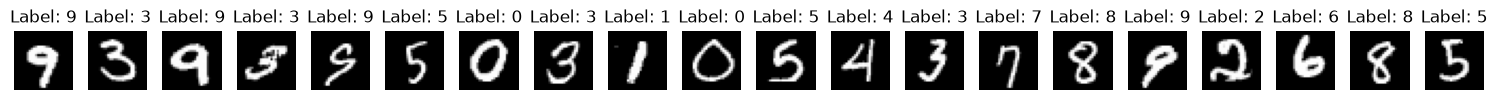

In [9]:
# Visualize some training samples
def show_samples(loader, num_samples=8):
    images, labels = next(iter(loader))
    images = images[:num_samples]
    labels = labels[:num_samples]
    
    # Denormalize for visualization
    mean, std = 0.1307, 0.3081
    images = images * std + mean
    
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
    for i, (img, label) in enumerate(zip(images, labels)):
        axes[i].imshow(img.squeeze(), cmap='gray')
        axes[i].set_title(f'Label: {label.item()}')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

show_samples(train_loader, 20)

---

## 2. Model Architecture: Multi-Layer Perceptron (MLP)

We'll build a flexible MLP class that allows experimenting with different:
- Number of hidden layers
- Hidden layer sizes
- Activation functions (ReLU, LeakyReLU, GELU, Tanh, Sigmoid)
- Dropout for regularization

In [10]:
class MLP(nn.Module):
    """
    Flexible Multi-Layer Perceptron for MNIST classification.
    
    Args:
        input_size: Input dimension (784 for flattened 28x28 MNIST)
        hidden_sizes: List of hidden layer sizes
        num_classes: Number of output classes (10 for MNIST)
        activation: Activation function name ('relu', 'leaky_relu', 'gelu', 'tanh', 'sigmoid')
        dropout: Dropout probability
    """
    def __init__(
        self,
        input_size=784,
        hidden_sizes=[256, 128],
        num_classes=10,
        activation='relu',
        dropout=0.2
    ):
        super().__init__()
        
        # Activation function mapping
        activations = {
            'relu': nn.ReLU(),
            'leaky_relu': nn.LeakyReLU(0.01),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh(),
            'sigmoid': nn.Sigmoid(),
        }
        
        if activation not in activations:
            raise ValueError(f"Unknown activation: {activation}. Choose from {list(activations.keys())}")
        
        self.activation_fn = activations[activation]
        self.dropout = nn.Dropout(dropout)
        
        # Build layers dynamically
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(self.activation_fn)
            layers.append(self.dropout)
            prev_size = hidden_size
        
        # Output layer (no activation, raw logits for CrossEntropyLoss)
        layers.append(nn.Linear(prev_size, num_classes))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        # Flatten input: (batch, 1, 28, 28) -> (batch, 784)
        x = x.view(x.size(0), -1)
        return self.network(x)
    
    def get_num_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

# Test the model
model = MLP(hidden_sizes=[256, 128], activation='relu', dropout=0.2)
print(f"Model architecture:\n{model}")
print(f"\nTotal trainable parameters: {model.get_num_parameters():,}")

# Test forward pass
x = torch.randn(4, 1, 28, 28)
output = model(x)
print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")

Model architecture:
MLP(
  (activation_fn): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total trainable parameters: 235,146
Input shape: torch.Size([4, 1, 28, 28])
Output shape: torch.Size([4, 10])


---

## 3. Training Setup

Define loss function, optimizer, and learning rate scheduler. We'll use:
- **CrossEntropyLoss**: Combines LogSoftmax + NLLLoss (expects raw logits)
- **Adam optimizer**: Adaptive learning rates, works well out of the box
- **Learning rate scheduler**: ReduceLROnPlateau to reduce LR when validation loss plateaus

In [12]:
def create_model_and_optimizer(
    hidden_sizes=[256, 128],
    activation='relu',
    dropout=0.2,
    lr=1e-3,
    weight_decay=1e-4
):
    """Factory function to create model, criterion, optimizer, and scheduler."""
    model = MLP(
        hidden_sizes=hidden_sizes,
        activation=activation,
        dropout=dropout
    ).to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    )
    
    return model, criterion, optimizer, scheduler

# Create default model
model, criterion, optimizer, scheduler = create_model_and_optimizer()
print(f"Model parameters: {model.get_num_parameters():,}")

Model parameters: 235,146


---

## 4. Training & Evaluation Functions

We'll create reusable functions for training one epoch and evaluating on validation/test sets.

In [13]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    """Evaluate model on a dataset."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc, np.array(all_preds), np.array(all_labels)

---

## 5. Training Loop

Train the model with early stopping and learning rate scheduling. We'll track training/validation loss and accuracy for visualization.

In [14]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    num_epochs=20,
    patience=7
):
    """
    Train model with early stopping and LR scheduling.
    Returns training history.
    """
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'lr': []
    }
    
    best_val_loss = float('inf')
    best_model_state = None
    epochs_no_improve = 0
    
    print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>9} | {'Val Acc':>8} | {'LR':>8}")
    print("-" * 70)
    
    for epoch in range(1, num_epochs + 1):
        # Training
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validation
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
        
        # Learning rate scheduling
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        
        # Record history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)
        
        # Print progress
        print(f"{epoch:>5} | {train_loss:>10.4f} | {train_acc:>9.2f} | {val_loss:>9.4f} | {val_acc:>8.2f} | {current_lr:>8.2e}")
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered after {epoch} epochs")
            break
    
    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    return history

# Train the model
print("Starting training...\n")
history = train_model(
    model, train_loader, val_loader,
    criterion, optimizer, scheduler,
    device, num_epochs=20, patience=7
)

Starting training...

Epoch | Train Loss | Train Acc |  Val Loss |  Val Acc |       LR
----------------------------------------------------------------------
    1 |     0.2975 |     91.04 |    0.1441 |    95.39 | 1.00e-03
    2 |     0.1405 |     95.68 |    0.1119 |    96.58 | 1.00e-03
    3 |     0.1077 |     96.65 |    0.1047 |    96.88 | 1.00e-03
    4 |     0.0901 |     97.23 |    0.0969 |    96.99 | 1.00e-03
    5 |     0.0804 |     97.48 |    0.0969 |    97.22 | 1.00e-03
    6 |     0.0701 |     97.88 |    0.0925 |    97.36 | 1.00e-03
    7 |     0.0675 |     97.83 |    0.0891 |    97.48 | 1.00e-03
    8 |     0.0617 |     98.03 |    0.0780 |    97.72 | 1.00e-03
    9 |     0.0573 |     98.13 |    0.0928 |    97.34 | 1.00e-03
   10 |     0.0572 |     98.14 |    0.0892 |    97.57 | 1.00e-03
   11 |     0.0497 |     98.32 |    0.0922 |    97.55 | 1.00e-03
   12 |     0.0519 |     98.29 |    0.0791 |    97.87 | 5.00e-04
   13 |     0.0316 |     98.94 |    0.0717 |    98.01 | 5.00e-

---

## 6. Visualize Training Curves

Plot training and validation loss/accuracy to diagnose overfitting/underfitting.

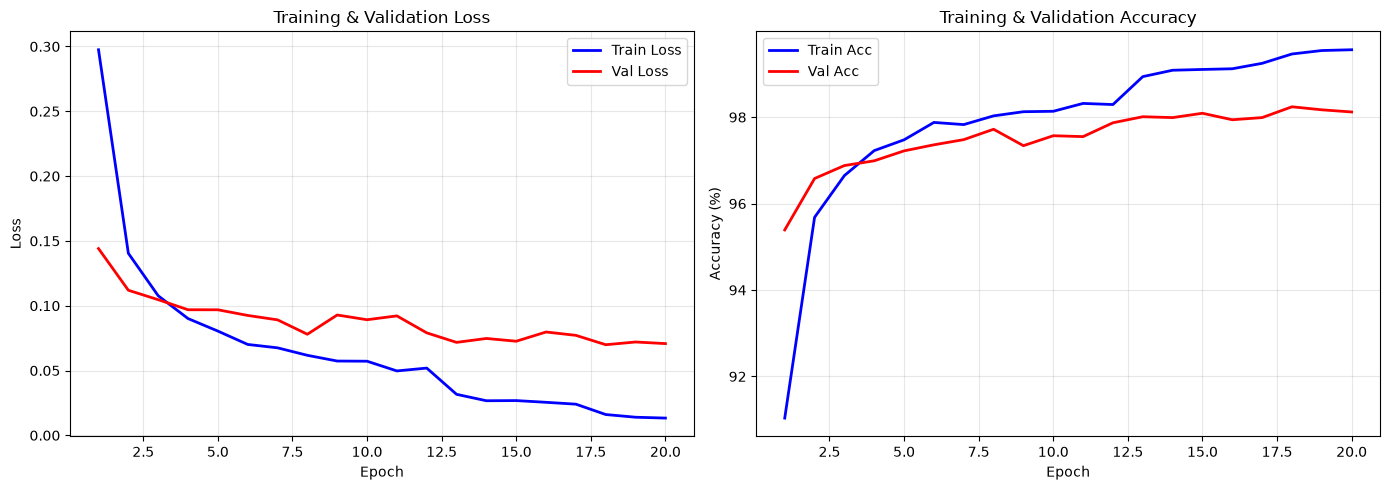

In [15]:
def plot_training_curves(history):
    """Plot training and validation curves."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Loss curves
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training & Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy curves
    axes[1].plot(epochs, history['train_acc'], 'b-', label='Train Acc', linewidth=2)
    axes[1].plot(epochs, history['val_acc'], 'r-', label='Val Acc', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Training & Validation Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_training_curves(history)

---

## 7. Test Set Evaluation

Evaluate the best model on the held-out test set and compute detailed metrics.

In [18]:
# Evaluate on test set
test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")

# Per-class accuracy
from sklearn.metrics import classification_report, confusion_matrix

print("\nPer-class Accuracy:")
for i in range(10):
    class_mask = (test_labels == i)
    if class_mask.sum() > 0:
        class_acc = 100. * (test_preds[class_mask] == test_labels[class_mask]).mean()
        print(f"  Digit {i}: {class_acc:.2f}% ({class_mask.sum()} samples)")

Test Loss: 0.0587
Test Accuracy: 98.48%

Per-class Accuracy:
  Digit 0: 99.29% (980 samples)
  Digit 1: 99.65% (1135 samples)
  Digit 2: 98.84% (1032 samples)
  Digit 3: 98.81% (1010 samples)
  Digit 4: 97.96% (982 samples)
  Digit 5: 97.65% (892 samples)
  Digit 6: 98.54% (958 samples)
  Digit 7: 98.93% (1028 samples)
  Digit 8: 97.13% (974 samples)
  Digit 9: 97.72% (1009 samples)


---

## 8. Confusion Matrix & Error Analysis

Visualize the confusion matrix to see which digits are commonly confused.

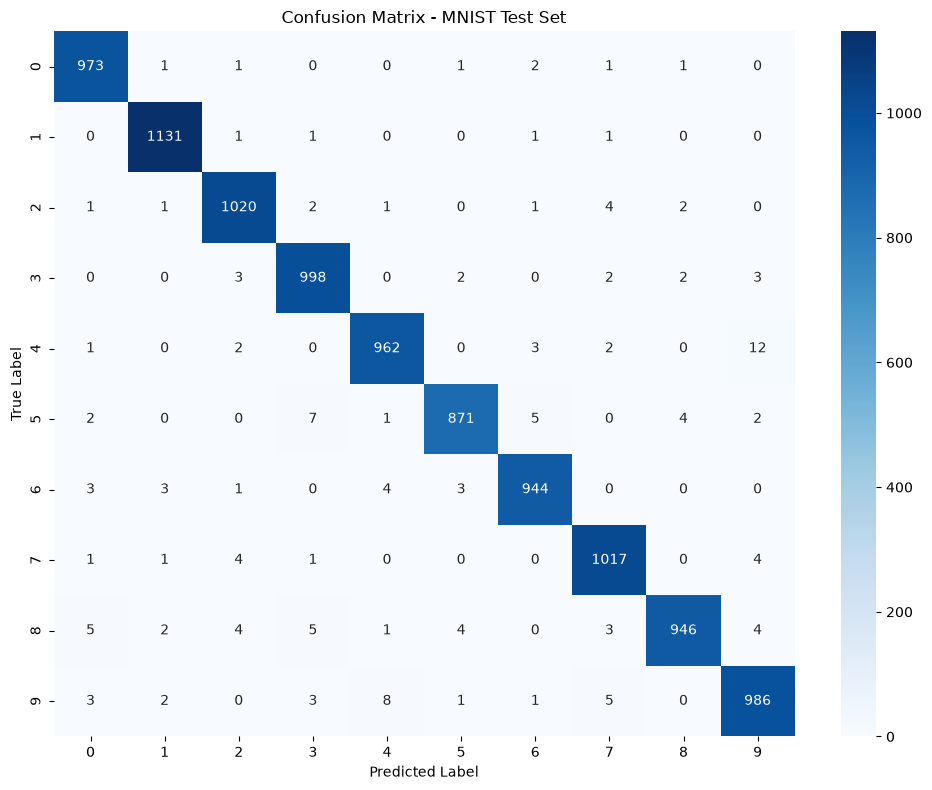

In [19]:
def plot_confusion_matrix(y_true, y_pred, classes=range(10)):
    """Plot confusion matrix with seaborn."""
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix - MNIST Test Set')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(test_labels, test_preds)

---

## 9. Visualize Predictions

Show correctly and incorrectly classified examples.

Correct Predictions:


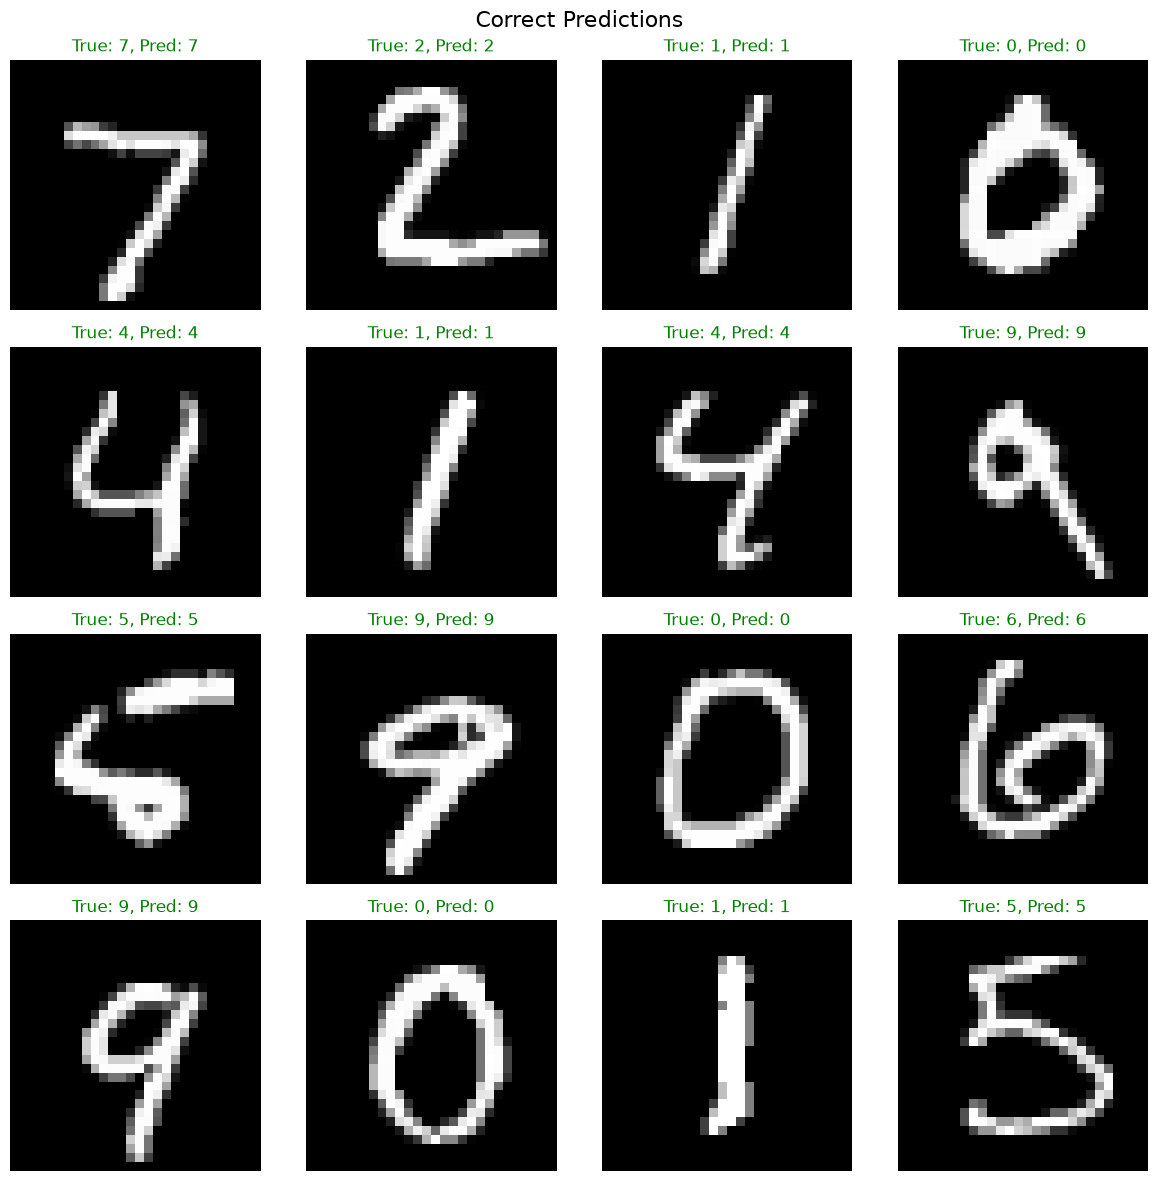

Incorrect Predictions:


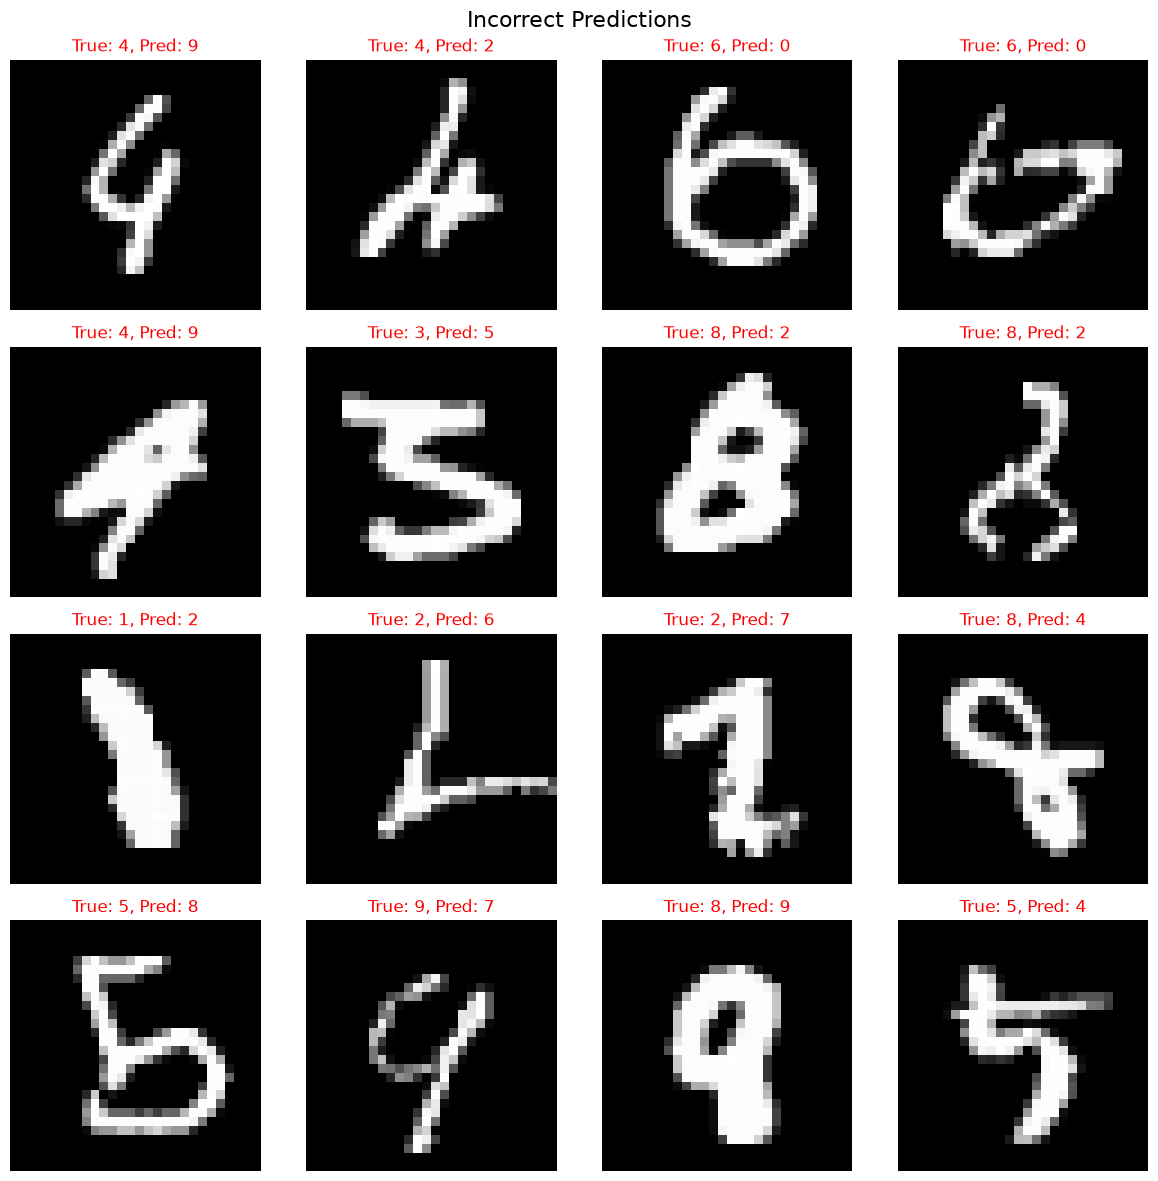

In [20]:
def visualize_predictions(loader, model, device, num_samples=16, correct=True):
    """Visualize correct or incorrect predictions."""
    model.eval()
    
    images_shown = 0
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    axes = axes.flatten()
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = outputs.max(1)
            
            # Denormalize for visualization
            mean, std = 0.1307, 0.3081
            images = images * std + mean
            
            for i in range(images.size(0)):
                is_correct = preds[i] == labels[i]
                if is_correct == correct and images_shown < num_samples:
                    ax = axes[images_shown]
                    ax.imshow(images[i].cpu().squeeze(), cmap='gray')
                    color = 'green' if is_correct else 'red'
                    ax.set_title(f'True: {labels[i].item()}, Pred: {preds[i].item()}', color=color)
                    ax.axis('off')
                    images_shown += 1
            
            if images_shown >= num_samples:
                break
    
    # Hide unused subplots
    for i in range(images_shown, num_samples):
        axes[i].axis('off')
    
    title = 'Correct Predictions' if correct else 'Incorrect Predictions'
    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

print("Correct Predictions:")
visualize_predictions(test_loader, model, device, correct=True)

print("Incorrect Predictions:")
visualize_predictions(test_loader, model, device, correct=False)

---

## 10. Architecture Experiments

Compare different architectures to find the best configuration. We'll test:
- Different hidden layer sizes
- Different activation functions
- Different dropout rates
- Different number of layers

In [21]:
def run_experiment(
    hidden_sizes,
    activation='relu',
    dropout=0.2,
    lr=1e-3,
    epochs=15,
    name=None
):
    """Run a single architecture experiment."""
    if name is None:
        name = f"{activation}_{'-'.join(map(str, hidden_sizes))}_drop{dropout}"
    
    print(f"\n{'='*60}")
    print(f"Experiment: {name}")
    print(f"{'='*60}")
    
    # Create model
    model, criterion, optimizer, scheduler = create_model_and_optimizer(
        hidden_sizes=hidden_sizes,
        activation=activation,
        dropout=dropout,
        lr=lr
    )
    
    # Train (fewer epochs for experiments)
    history = train_model(
        model, train_loader, val_loader,
        criterion, optimizer, scheduler,
        device, num_epochs=epochs, patience=5
    )
    
    # Test evaluation
    test_loss, test_acc, _, _ = evaluate(model, test_loader, criterion, device)
    
    print(f"\nFinal Test Accuracy: {test_acc:.2f}%")
    
    return {
        'name': name,
        'model': model,
        'history': history,
        'test_acc': test_acc,
        'test_loss': test_loss,
        'params': model.get_num_parameters()
    }

# Define experiments to run
experiments = [
    # Baseline
    {'hidden_sizes': [256, 128], 'activation': 'relu', 'dropout': 0.2, 'name': 'Baseline (256-128, ReLU)'},
    
    # Different architectures
    {'hidden_sizes': [512, 256], 'activation': 'relu', 'dropout': 0.2, 'name': 'Larger (512-256, ReLU)'},
    {'hidden_sizes': [128, 64], 'activation': 'relu', 'dropout': 0.2, 'name': 'Smaller (128-64, ReLU)'},
    {'hidden_sizes': [256, 128, 64], 'activation': 'relu', 'dropout': 0.2, 'name': 'Deeper (256-128-64, ReLU)'},
    
    # Different activations
    {'hidden_sizes': [256, 128], 'activation': 'leaky_relu', 'dropout': 0.2, 'name': 'LeakyReLU (256-128)'},
    {'hidden_sizes': [256, 128], 'activation': 'gelu', 'dropout': 0.2, 'name': 'GELU (256-128)'},
    {'hidden_sizes': [256, 128], 'activation': 'tanh', 'dropout': 0.2, 'name': 'Tanh (256-128)'},
    
    # Different dropout
    {'hidden_sizes': [256, 128], 'activation': 'relu', 'dropout': 0.0, 'name': 'No Dropout (256-128)'},
    {'hidden_sizes': [256, 128], 'activation': 'relu', 'dropout': 0.5, 'name': 'High Dropout (256-128)'},
]

In [22]:
# Run all experiments (this will take a few minutes)
results = []

for exp_config in experiments:
    result = run_experiment(
        hidden_sizes=exp_config['hidden_sizes'],
        activation=exp_config['activation'],
        dropout=exp_config['dropout'],
        name=exp_config['name'],
        epochs=10  # Fewer epochs for quick comparison
    )
    results.append(result)


Experiment: Baseline (256-128, ReLU)
Epoch | Train Loss | Train Acc |  Val Loss |  Val Acc |       LR
----------------------------------------------------------------------
    1 |     0.3009 |     90.83 |    0.1500 |    95.45 | 1.00e-03
    2 |     0.1421 |     95.65 |    0.1194 |    96.38 | 1.00e-03
    3 |     0.1063 |     96.78 |    0.1039 |    96.77 | 1.00e-03
    4 |     0.0916 |     97.19 |    0.0906 |    97.30 | 1.00e-03
    5 |     0.0791 |     97.50 |    0.0941 |    97.29 | 1.00e-03
    6 |     0.0735 |     97.61 |    0.0917 |    97.45 | 1.00e-03
    7 |     0.0677 |     97.84 |    0.0920 |    97.52 | 1.00e-03
    8 |     0.0628 |     97.96 |    0.0955 |    97.27 | 5.00e-04
    9 |     0.0371 |     98.77 |    0.0796 |    97.85 | 5.00e-04
   10 |     0.0335 |     98.90 |    0.0759 |    97.85 | 5.00e-04

Final Test Accuracy: 98.28%

Experiment: Larger (512-256, ReLU)
Epoch | Train Loss | Train Acc |  Val Loss |  Val Acc |       LR
----------------------------------------------

---

## 11. Compare Experiment Results

Summarize and visualize the results of all architecture experiments.

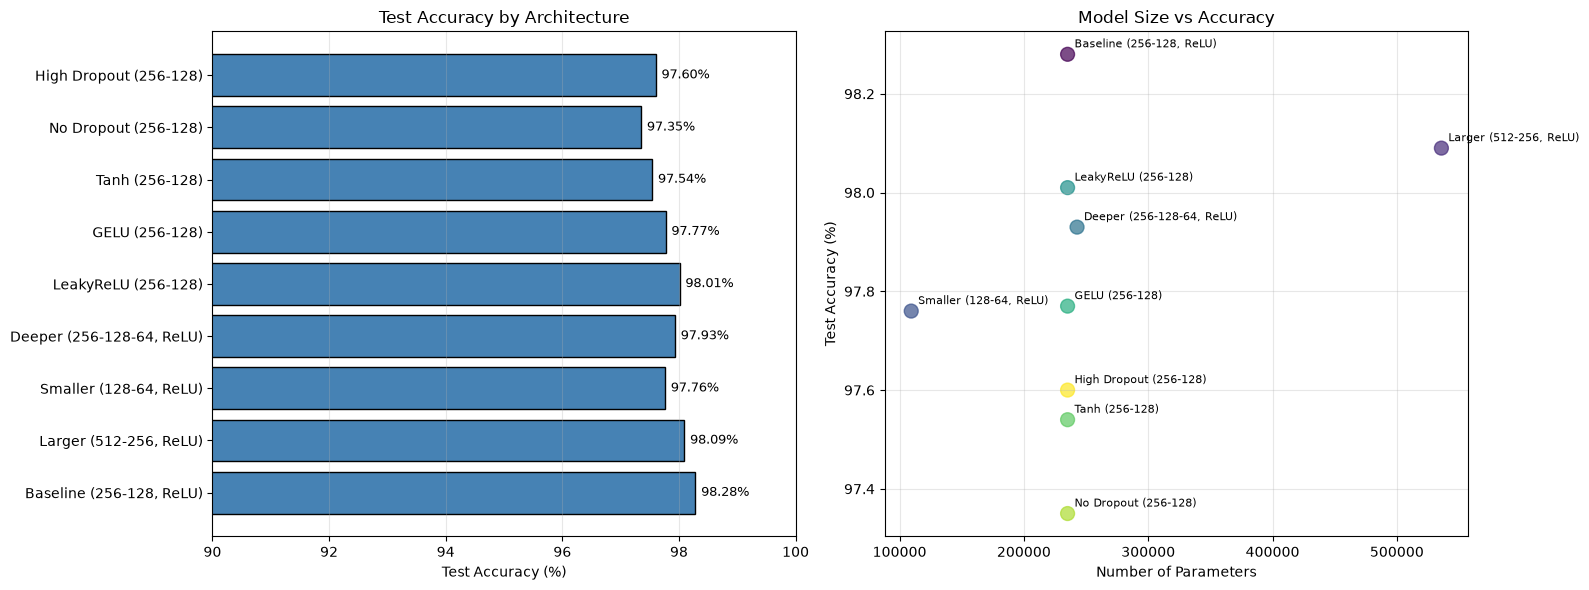

In [23]:
def plot_experiment_comparison(results):
    """Plot comparison of experiment results."""
    names = [r['name'] for r in results]
    test_accs = [r['test_acc'] for r in results]
    params = [r['params'] for r in results]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Test accuracy comparison
    bars = axes[0].barh(range(len(names)), test_accs, color='steelblue', edgecolor='black')
    axes[0].set_yticks(range(len(names)))
    axes[0].set_yticklabels(names)
    axes[0].set_xlabel('Test Accuracy (%)')
    axes[0].set_title('Test Accuracy by Architecture')
    axes[0].set_xlim(90, 100)
    axes[0].grid(True, alpha=0.3, axis='x')
    
    # Add value labels on bars
    for i, (bar, acc) in enumerate(zip(bars, test_accs)):
        axes[0].text(acc + 0.1, bar.get_y() + bar.get_height()/2, 
                    f'{acc:.2f}%', va='center', fontsize=9)
    
    # Parameters vs Accuracy
    scatter = axes[1].scatter(params, test_accs, c=range(len(results)), cmap='viridis', s=100, alpha=0.7)
    for i, name in enumerate(names):
        axes[1].annotate(name, (params[i], test_accs[i]), 
                        xytext=(5, 5), textcoords='offset points', fontsize=8)
    axes[1].set_xlabel('Number of Parameters')
    axes[1].set_ylabel('Test Accuracy (%)')
    axes[1].set_title('Model Size vs Accuracy')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

if results:
    plot_experiment_comparison(results)

In [24]:
# Print summary table
if results:
    print(f"{'Model':<35} {'Params':>10} {'Test Acc':>10} {'Test Loss':>10}")
    print("-" * 70)
    for r in sorted(results, key=lambda x: x['test_acc'], reverse=True):
        print(f"{r['name']:<35} {r['params']:>10,} {r['test_acc']:>10.2f}% {r['test_loss']:>10.4f}")

Model                                   Params   Test Acc  Test Loss
----------------------------------------------------------------------
Baseline (256-128, ReLU)               235,146      98.28%     0.0641
Larger (512-256, ReLU)                 535,818      98.09%     0.0670
LeakyReLU (256-128)                    235,146      98.01%     0.0657
Deeper (256-128-64, ReLU)              242,762      97.93%     0.0709
GELU (256-128)                         235,146      97.77%     0.0769
Smaller (128-64, ReLU)                 109,386      97.76%     0.0769
High Dropout (256-128)                 235,146      97.60%     0.0832
Tanh (256-128)                         235,146      97.54%     0.0780
No Dropout (256-128)                   235,146      97.35%     0.0941


---

## 12. Save Best Model

Save the best performing model for future use.

In [25]:
# Find best model
if results:
    best_result = max(results, key=lambda x: x['test_acc'])
    best_model = best_result['model']
    
    # Save model
    save_path = 'best_mnist_mlp.pth'
    torch.save({
        'model_state_dict': best_model.state_dict(),
        'model_config': {
            'hidden_sizes': [256, 128],  # Update based on best model
            'activation': 'relu',
            'dropout': 0.2
        },
        'test_accuracy': best_result['test_acc'],
        'num_parameters': best_result['params']
    }, save_path)
    
    print(f"Best model saved to {save_path}")
    print(f"Best model: {best_result['name']}")
    print(f"Test Accuracy: {best_result['test_acc']:.2f}%")
    print(f"Parameters: {best_result['params']:,}")

Best model saved to best_mnist_mlp.pth
Best model: Baseline (256-128, ReLU)
Test Accuracy: 98.28%
Parameters: 235,146


---

## 13. Load and Use Saved Model

Demonstrate how to load the saved model for inference.

In [26]:
def load_model(checkpoint_path, device):
    """Load a saved model checkpoint."""
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    config = checkpoint['model_config']
    model = MLP(
        hidden_sizes=config['hidden_sizes'],
        activation=config['activation'],
        dropout=config['dropout']
    ).to(device)
    
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    return model, checkpoint

# Load and test
if os.path.exists('best_mnist_mlp.pth'):
    loaded_model, checkpoint = load_model('best_mnist_mlp.pth', device)
    
    # Quick test
    test_loss, test_acc, _, _ = evaluate(loaded_model, test_loader, criterion, device)
    print(f"Loaded model test accuracy: {test_acc:.2f}%")
    print(f"Checkpoint test accuracy: {checkpoint['test_accuracy']:.2f}%")

Loaded model test accuracy: 98.28%
Checkpoint test accuracy: 98.28%


---

## 14. Inference on New Data

Example of how to use the trained model for inference on new images.

In [27]:
def predict_digit(model, image_tensor, device):
    """Predict digit from a single image tensor."""
    model.eval()
    with torch.no_grad():
        image_tensor = image_tensor.to(device)
        if image_tensor.dim() == 3:
            image_tensor = image_tensor.unsqueeze(0)  # Add batch dim
        output = model(image_tensor)
        probabilities = F.softmax(output, dim=1)
        confidence, predicted = probabilities.max(1)
    return predicted.item(), confidence.item(), probabilities.cpu().numpy()[0]

# Test on a few test images
model.eval()
images, labels = next(iter(test_loader))
images = images[:5].to(device)
labels = labels[:5]

print("Inference Examples:")
print("-" * 50)
for i in range(5):
    pred, conf, probs = predict_digit(model, images[i], device)
    true_label = labels[i].item()
    correct = "✓" if pred == true_label else "✗"
    print(f"Image {i+1}: True={true_label}, Pred={pred}, Conf={conf:.4f} {correct}")
    print(f"  Probabilities: {np.round(probs, 4)}")

Inference Examples:
--------------------------------------------------
Image 1: True=7, Pred=7, Conf=1.0000 ✓
  Probabilities: [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
Image 2: True=2, Pred=2, Conf=1.0000 ✓
  Probabilities: [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
Image 3: True=1, Pred=1, Conf=1.0000 ✓
  Probabilities: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
Image 4: True=0, Pred=0, Conf=1.0000 ✓
  Probabilities: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Image 5: True=4, Pred=4, Conf=0.9998 ✓
  Probabilities: [0.000e+00 0.000e+00 0.000e+00 0.000e+00 9.998e-01 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 2.000e-04]


---

## 15. Summary & Key Takeaways

### What We Built
1. **Complete MNIST Classification Pipeline** - From data loading to model deployment
2. **Flexible MLP Architecture** - Configurable layers, activations, dropout
3. **Robust Training Loop** - With early stopping, LR scheduling, and validation
4. **Comprehensive Evaluation** - Accuracy, confusion matrix, error analysis
5. **Architecture Search** - Systematic comparison of different configurations

### Best Practices Demonstrated
- **Data normalization** using dataset statistics (mean=0.1307, std=0.3081)
- **Train/Val/Test split** for unbiased evaluation
- **CrossEntropyLoss** with raw logits (no softmax in model)
- **Adam optimizer** with weight decay for regularization
- **Learning rate scheduling** (ReduceLROnPlateau)
- **Early stopping** to prevent overfitting
- **Dropout** for regularization
- **Model checkpointing** (save best validation model)

### Expected Results
- **Baseline MLP (256-128, ReLU)**: ~97-98% test accuracy
- **Larger models**: Can reach 98%+ but with more parameters
- **CNNs** (next lesson): Can achieve 99%+ with fewer parameters

### Next Steps (Day 2+)
- Optimization & Regularizaiton for better performance
- Data augmentation techniques

---

**End of Day 1 Project Notebook**

*Summer School on AI 2026 - Neural Networks & Math*